# 01 - VietNews Data QA (Processed Dataset)

This notebook is the official data quality assurance artifact for the processed VietNews split used in the thesis benchmark pipeline.

Core questions:
1. Does the processed split satisfy the required schema and metadata coverage?
2. Is the processed text consistent with the frozen preprocessing protocol?
3. Are the basic distribution statistics reasonable for later benchmarking and reporting?


## 1. Environment Setup

This notebook only audits `data/processed/vietnews/` and the corresponding manifest.
It does not validate raw-to-processed conversion correctness end-to-end; instead, it checks protocol consistency on the already processed split.

In [76]:
from __future__ import annotations

import json
import platform
import random
import subprocess
import sys
from datetime import datetime
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if (ROOT / "backend").exists():
    PROJECT_ROOT = ROOT
elif (ROOT.parent / "backend").exists():
    PROJECT_ROOT = ROOT.parent
else:
    raise RuntimeError("Repository root not found. Open the notebook from the repo root or notebooks/.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / "evaluation") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "evaluation"))

from preprocess import preprocess_and_split

pd.set_option("display.max_colwidth", 220)


def safe_version(package_name: str) -> str | None:
    try:
        return version(package_name)
    except PackageNotFoundError:
        return None


def safe_git_commit(repo_root: Path) -> str | None:
    try:
        result = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            cwd=repo_root,
            check=True,
            capture_output=True,
            text=True,
        )
        return result.stdout.strip()
    except Exception:
        return None


def is_git_dirty(repo_root: Path) -> bool | None:
    try:
        result = subprocess.run(
            ["git", "status", "--porcelain"],
            cwd=repo_root,
            check=True,
            capture_output=True,
            text=True,
        )
        return bool(result.stdout.strip())
    except Exception:
        return None


environment_snapshot = {
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "matplotlib_version": safe_version("matplotlib"),
    "git_commit": safe_git_commit(PROJECT_ROOT),
    "git_dirty": is_git_dirty(PROJECT_ROOT),
}

print("PROJECT_ROOT:", PROJECT_ROOT)
environment_snapshot


PROJECT_ROOT: C:\Users\OS\OneDrive\Desktop\Text_Summarization


{'python_version': '3.10.20',
 'platform': 'Windows-10-10.0.26200-SP0',
 'pandas_version': '2.3.3',
 'numpy_version': '2.2.6',
 'matplotlib_version': '3.10.8',
 'git_commit': 'c5f2468d3b654fd7e944f9edf35afe1d504e936c',
 'git_dirty': True}

## 2. Configuration

The data QA notebook should use the same official split and seed family as the benchmark notebook.

In [77]:
NOTEBOOK_SCHEMA_VERSION = "vietnews_data_qa_v2"
PROTOCOL_VERSION_EXPECTED = "phase0_v2"
TARGET_SPLIT = "validation"
SEED = 42
PREPROCESS_CHECK_N = 500
SENTENCE_RECHECK_N = 1000
SAMPLE_N = 5
PASS_EMPTY_RATIO_THRESHOLD = 0.001
ACCEPTABLE_SENTENCE_MISMATCH_RATE_THRESHOLD = 0.01

random.seed(SEED)
np.random.seed(SEED)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "vietnews"
MANIFEST_PATH = PROCESSED_DIR / "dataset_manifest.json"
SPLIT_PATH = PROCESSED_DIR / f"{TARGET_SPLIT}.jsonl"

config_snapshot = {
    "notebook_schema_version": NOTEBOOK_SCHEMA_VERSION,
    "protocol_version_expected": PROTOCOL_VERSION_EXPECTED,
    "target_split": TARGET_SPLIT,
    "seed": SEED,
    "preprocess_check_n": PREPROCESS_CHECK_N,
    "sentence_recheck_n": SENTENCE_RECHECK_N,
    "sample_n": SAMPLE_N,
    "pass_empty_ratio_threshold": PASS_EMPTY_RATIO_THRESHOLD,
    "acceptable_sentence_mismatch_rate_threshold": ACCEPTABLE_SENTENCE_MISMATCH_RATE_THRESHOLD,
}
config_snapshot


{'notebook_schema_version': 'vietnews_data_qa_v2',
 'protocol_version_expected': 'phase0_v2',
 'target_split': 'validation',
 'seed': 42,
 'preprocess_check_n': 500,
 'sentence_recheck_n': 1000,
 'sample_n': 5,
 'pass_empty_ratio_threshold': 0.001,
 'acceptable_sentence_mismatch_rate_threshold': 0.01}

## 3. Load The Processed Split And Manifest

The official benchmark split is set to `validation` by default so that this notebook aligns with the benchmark notebook narrative.

In [78]:
if not PROCESSED_DIR.exists():
    raise FileNotFoundError(f"Processed directory not found: {PROCESSED_DIR}")
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Manifest not found: {MANIFEST_PATH}")
if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"Processed split file not found: {SPLIT_PATH}")

with MANIFEST_PATH.open("r", encoding="utf-8") as f:
    manifest = json.load(f)

protocol_version = manifest.get("protocol_version")
if protocol_version != PROTOCOL_VERSION_EXPECTED:
    raise RuntimeError(
        f"Protocol version mismatch: expected {PROTOCOL_VERSION_EXPECTED!r}, got {protocol_version!r}"
    )

rows: list[dict] = []
with SPLIT_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("The processed split is empty.")

print("Available processed files:", sorted(p.name for p in PROCESSED_DIR.glob("*")))
print("Loaded split:", TARGET_SPLIT)
print("Rows:", len(df))
df.head(2)


Available processed files: ['dataset_manifest.json', 'test.jsonl', 'train.jsonl', 'validation.jsonl']
Loaded split: validation
Rows: 22184


,guid,title,article,reference_summary,meta
0,1,"Khởi_tố , tạm giam hai nhân_viên công_ty Địa_ốc Alibaba chống lệnh cưỡng_chế","Ngày 22/6 , cơ_quan CSĐT Công_an T X.Phú Mỹ đã ra quyết_định khởi_tố vụ án hình_sự về các tội Gây_rối trật_tự công_cộng và Cố_ý làm hư_hỏng tài_sản ; ra quyết_định khởi_tố bị_can , lệnh tạm giam đối_với Nguyễn_Huỳnh_...","Viện_kiểm_sát nhân_dân T X.Phú Mỹ , tỉnh Bà_Rịa – Vũng_Tàu vừa phê_chuẩn quyết_định khởi_tố bị_can , lệnh tạm giam đối_với 2 nhân_viên công_ty Địa_ốc Alibaba là Nguyễn_Huỳnh_Tú_Trinh và Trần_Quốc_Tĩnh về hành_vi cố_ý...","{'protocol_version': 'phase0_v2', 'article_char_len': 3578, 'reference_summary_char_len': 238, 'article_sentence_count': 22, 'reference_summary_sentence_count': 1}"
1,2,Án chung_thân cho đối_tượng giết vợ vì ghen_tuông,"Theo cáo_trạng , năm 2013 , Tiến và chị Phạm_Thị_Huyền_Tr . ( SN 1997 ) kết_hôn . Sau 5 chung sống , hai người thường_xuyên xảy ra mâu_thuẫn , cơm không lành , canh không ngọt . Do_đó , đầu năm 2018 , Tr . quyết_định...","Ngày 19/9 , TAND tỉnh Đắk_Nông mở phiên_toà sơ_thẩm xét_xử vụ án hình_sự đối_với bị_cáo Trần_Anh_Tiến ( SN 1992 , ngụ thôn Thuận_Hạnh , huyện Đắk_Mil , tỉnh Đắk_Nông ) về tội Giết người .","{'protocol_version': 'phase0_v2', 'article_char_len': 1173, 'reference_summary_char_len': 187, 'article_sentence_count': 21, 'reference_summary_sentence_count': 1}"


## 4. Schema Integrity And Pass Conditions

This section confirms that the processed split contains the required columns and metadata keys.
The main pass conditions are:
- all required columns are present
- metadata key coverage is 100%
- `article` and `reference_summary` empty ratios are near zero


In [79]:
required_cols = ["guid", "title", "article", "reference_summary", "meta"]
required_meta_keys = [
    "protocol_version",
    "article_char_len",
    "reference_summary_char_len",
    "article_sentence_count",
    "reference_summary_sentence_count",
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")


def has_meta_key(meta: object, key: str) -> bool:
    return isinstance(meta, dict) and key in meta


schema_rows: list[dict] = []
for col in required_cols:
    null_count = int(df[col].isna().sum())
    empty_count = int((df[col].fillna("").astype(str).str.strip() == "").sum()) if col != "meta" else 0
    schema_rows.append(
        {
            "column": col,
            "dtype": str(df[col].dtype),
            "null_count": null_count,
            "empty_count": empty_count,
            "empty_ratio": (empty_count / len(df)) if len(df) and col != "meta" else 0.0,
        }
    )

schema_df = pd.DataFrame(schema_rows)

meta_schema_df = pd.DataFrame(
    [
        {
            "meta_key": key,
            "present_ratio": float(df["meta"].map(lambda m: has_meta_key(m, key)).mean()) if len(df) else 0.0,
        }
        for key in required_meta_keys
    ]
)

article_empty_ratio = float(schema_df.loc[schema_df["column"] == "article", "empty_ratio"].iloc[0])
reference_empty_ratio = float(schema_df.loc[schema_df["column"] == "reference_summary", "empty_ratio"].iloc[0])
meta_keys_full = bool((meta_schema_df["present_ratio"] == 1.0).all())

pass_conditions = {
    "required_columns_present": len(missing_cols) == 0,
    "meta_key_coverage_is_100_percent": meta_keys_full,
    "article_empty_ratio_near_zero": article_empty_ratio <= PASS_EMPTY_RATIO_THRESHOLD,
    "reference_summary_empty_ratio_near_zero": reference_empty_ratio <= PASS_EMPTY_RATIO_THRESHOLD,
}

display(meta_schema_df)
display(schema_df)
pass_conditions


,meta_key,present_ratio
0,protocol_version,1.0
1,article_char_len,1.0
2,reference_summary_char_len,1.0
3,article_sentence_count,1.0
4,reference_summary_sentence_count,1.0


,column,dtype,null_count,empty_count,empty_ratio
0,guid,int64,0,0,0.0
1,title,object,0,0,0.0
2,article,object,0,0,0.0
3,reference_summary,object,0,0,0.0
4,meta,object,0,0,0.0


{'required_columns_present': True,
 'meta_key_coverage_is_100_percent': True,
 'article_empty_ratio_near_zero': True,
 'reference_summary_empty_ratio_near_zero': True}

## 5. Protocol Consistency Check

This section compares metadata against recomputed values from the protocol-aligned preprocessing helper.
If sentence-count mismatches remain, they should be documented as tokenization or sentence-splitting drift and interpreted according to their magnitude.

In [80]:
check_n = min(PREPROCESS_CHECK_N, len(df))
check_df = df.sample(n=check_n, random_state=SEED).copy() if len(df) else df.copy()

article_char_mismatch = 0
reference_char_mismatch = 0
article_sentence_mismatch = 0
reference_sentence_mismatch = 0
protocol_version_mismatch = 0

for _, row in check_df.iterrows():
    meta = row.get("meta") or {}
    article_text, article_sents = preprocess_and_split(row.get("article"))
    reference_text, reference_sents = preprocess_and_split(row.get("reference_summary"))

    if len(article_text) != int(meta.get("article_char_len", -1)):
        article_char_mismatch += 1
    if len(reference_text) != int(meta.get("reference_summary_char_len", -1)):
        reference_char_mismatch += 1
    if len(article_sents) != int(meta.get("article_sentence_count", -1)):
        article_sentence_mismatch += 1
    if len(reference_sents) != int(meta.get("reference_summary_sentence_count", -1)):
        reference_sentence_mismatch += 1
    if str(meta.get("protocol_version")) != str(protocol_version):
        protocol_version_mismatch += 1

preprocess_check = {
    "sample_size": int(check_n),
    "manifest_protocol_version": protocol_version,
    "article_char_mismatch": int(article_char_mismatch),
    "reference_char_mismatch": int(reference_char_mismatch),
    "article_sentence_mismatch": int(article_sentence_mismatch),
    "reference_sentence_mismatch": int(reference_sentence_mismatch),
    "protocol_version_mismatch": int(protocol_version_mismatch),
}

sentence_mismatch_total = article_sentence_mismatch + reference_sentence_mismatch
sentence_mismatch_rate = (sentence_mismatch_total / (2 * check_n)) if check_n > 0 else 0.0

preprocess_interpretation = {
    "preprocessing_consistent_strict": (
        article_char_mismatch == 0
        and reference_char_mismatch == 0
        and article_sentence_mismatch == 0
        and reference_sentence_mismatch == 0
        and protocol_version_mismatch == 0
    ),
    "acceptable_for_benchmark": (
        article_char_mismatch == 0
        and reference_char_mismatch == 0
        and protocol_version_mismatch == 0
        and sentence_mismatch_rate <= ACCEPTABLE_SENTENCE_MISMATCH_RATE_THRESHOLD
    ),
    "sentence_mismatch_rate": float(sentence_mismatch_rate),
    "possible_cause_if_nonzero": (
        "Sentence-count mismatches typically indicate sentence-splitting drift or tokenization differences "
        "between the stored metadata and the current preprocessing helper."
        if sentence_mismatch_total > 0
        else "No sentence-count mismatch detected in the sampled audit set."
    ),
    "impact_assessment": (
        "Low impact"
        if sentence_mismatch_rate <= ACCEPTABLE_SENTENCE_MISMATCH_RATE_THRESHOLD
        else "Requires manual inspection"
    ),
}

preprocess_check, preprocess_interpretation


({'sample_size': 500,
  'manifest_protocol_version': 'phase0_v2',
  'article_char_mismatch': 0,
  'reference_char_mismatch': 0,
  'article_sentence_mismatch': 213,
  'reference_sentence_mismatch': 61,
  'protocol_version_mismatch': 0},
 {'preprocessing_consistent_strict': False,
  'acceptable_for_benchmark': False,
  'sentence_mismatch_rate': 0.274,
  'possible_cause_if_nonzero': 'Sentence-count mismatches typically indicate sentence-splitting drift or tokenization differences between the stored metadata and the current preprocessing helper.',
  'impact_assessment': 'Requires manual inspection'})

## 6. Length Statistics For Thesis Reporting

These summary tables are intended to feed directly into the data description section of the thesis.

In [81]:
df["article_char_len"] = df["meta"].map(lambda m: (m or {}).get("article_char_len", 0))
df["reference_char_len"] = df["meta"].map(lambda m: (m or {}).get("reference_summary_char_len", 0))
df["article_token_count"] = df["article"].fillna("").astype(str).str.split().str.len()
df["reference_token_count"] = df["reference_summary"].fillna("").astype(str).str.split().str.len()

length_stats = pd.DataFrame(
    [
        {
            "metric": "article_char_len",
            "mean": float(df["article_char_len"].mean()),
            "p50": float(df["article_char_len"].quantile(0.50)),
            "p90": float(df["article_char_len"].quantile(0.90)),
            "p95": float(df["article_char_len"].quantile(0.95)),
            "max": float(df["article_char_len"].max()),
        },
        {
            "metric": "reference_char_len",
            "mean": float(df["reference_char_len"].mean()),
            "p50": float(df["reference_char_len"].quantile(0.50)),
            "p90": float(df["reference_char_len"].quantile(0.90)),
            "p95": float(df["reference_char_len"].quantile(0.95)),
            "max": float(df["reference_char_len"].max()),
        },
        {
            "metric": "article_token_count",
            "mean": float(df["article_token_count"].mean()),
            "p50": float(df["article_token_count"].quantile(0.50)),
            "p90": float(df["article_token_count"].quantile(0.90)),
            "p95": float(df["article_token_count"].quantile(0.95)),
            "max": float(df["article_token_count"].max()),
        },
        {
            "metric": "reference_token_count",
            "mean": float(df["reference_token_count"].mean()),
            "p50": float(df["reference_token_count"].quantile(0.50)),
            "p90": float(df["reference_token_count"].quantile(0.90)),
            "p95": float(df["reference_token_count"].quantile(0.95)),
            "max": float(df["reference_token_count"].max()),
        },
    ]
)
length_stats


,metric,mean,p50,p90,p95,max
0,article_char_len,2304.536918,1986.0,4020.0,4635.00,11439.0
1,reference_char_len,158.512261,149.0,217.0,238.00,628.0
2,article_token_count,418.651821,360.0,735.0,843.85,1875.0
3,reference_token_count,28.471150,27.0,40.0,44.00,108.0


## 7. Sentence Statistics And Ground-Truth Compression Ratio

In [82]:
df["article_sentence_count"] = df["meta"].map(lambda m: (m or {}).get("article_sentence_count", 0))
df["reference_sentence_count"] = df["meta"].map(lambda m: (m or {}).get("reference_summary_sentence_count", 0))

sentence_stats = pd.DataFrame(
    [
        {
            "metric": "article_sentence_count",
            "mean": float(df["article_sentence_count"].mean()),
            "p50": float(df["article_sentence_count"].quantile(0.50)),
            "p90": float(df["article_sentence_count"].quantile(0.90)),
            "p95": float(df["article_sentence_count"].quantile(0.95)),
            "max": float(df["article_sentence_count"].max()),
        },
        {
            "metric": "reference_sentence_count",
            "mean": float(df["reference_sentence_count"].mean()),
            "p50": float(df["reference_sentence_count"].quantile(0.50)),
            "p90": float(df["reference_sentence_count"].quantile(0.90)),
            "p95": float(df["reference_sentence_count"].quantile(0.95)),
            "max": float(df["reference_sentence_count"].max()),
        },
    ]
)

df["compression_ratio_chars"] = df["reference_char_len"] / df["article_char_len"].clip(lower=1)
df["compression_ratio_sentences"] = df["reference_sentence_count"] / df["article_sentence_count"].clip(lower=1)

compression_stats = pd.DataFrame(
    [
        {
            "metric": "compression_ratio_chars",
            "mean": float(df["compression_ratio_chars"].mean()),
            "p50": float(df["compression_ratio_chars"].quantile(0.50)),
            "p90": float(df["compression_ratio_chars"].quantile(0.90)),
            "min": float(df["compression_ratio_chars"].min()),
            "max": float(df["compression_ratio_chars"].max()),
        },
        {
            "metric": "compression_ratio_sentences",
            "mean": float(df["compression_ratio_sentences"].mean()),
            "p50": float(df["compression_ratio_sentences"].quantile(0.50)),
            "p90": float(df["compression_ratio_sentences"].quantile(0.90)),
            "min": float(df["compression_ratio_sentences"].min()),
            "max": float(df["compression_ratio_sentences"].max()),
        },
    ]
)

display(sentence_stats)
compression_stats


,metric,mean,p50,p90,p95,max
0,article_sentence_count,18.166922,16.0,32.0,37.0,97.0
1,reference_sentence_count,1.264335,1.0,2.0,2.0,7.0


,metric,mean,p50,p90,min,max
0,compression_ratio_chars,0.083962,0.076113,0.137977,0.008298,0.588679
1,compression_ratio_sentences,0.082676,0.076923,0.136364,0.013514,1.000000


## 8. Distribution Visualizations

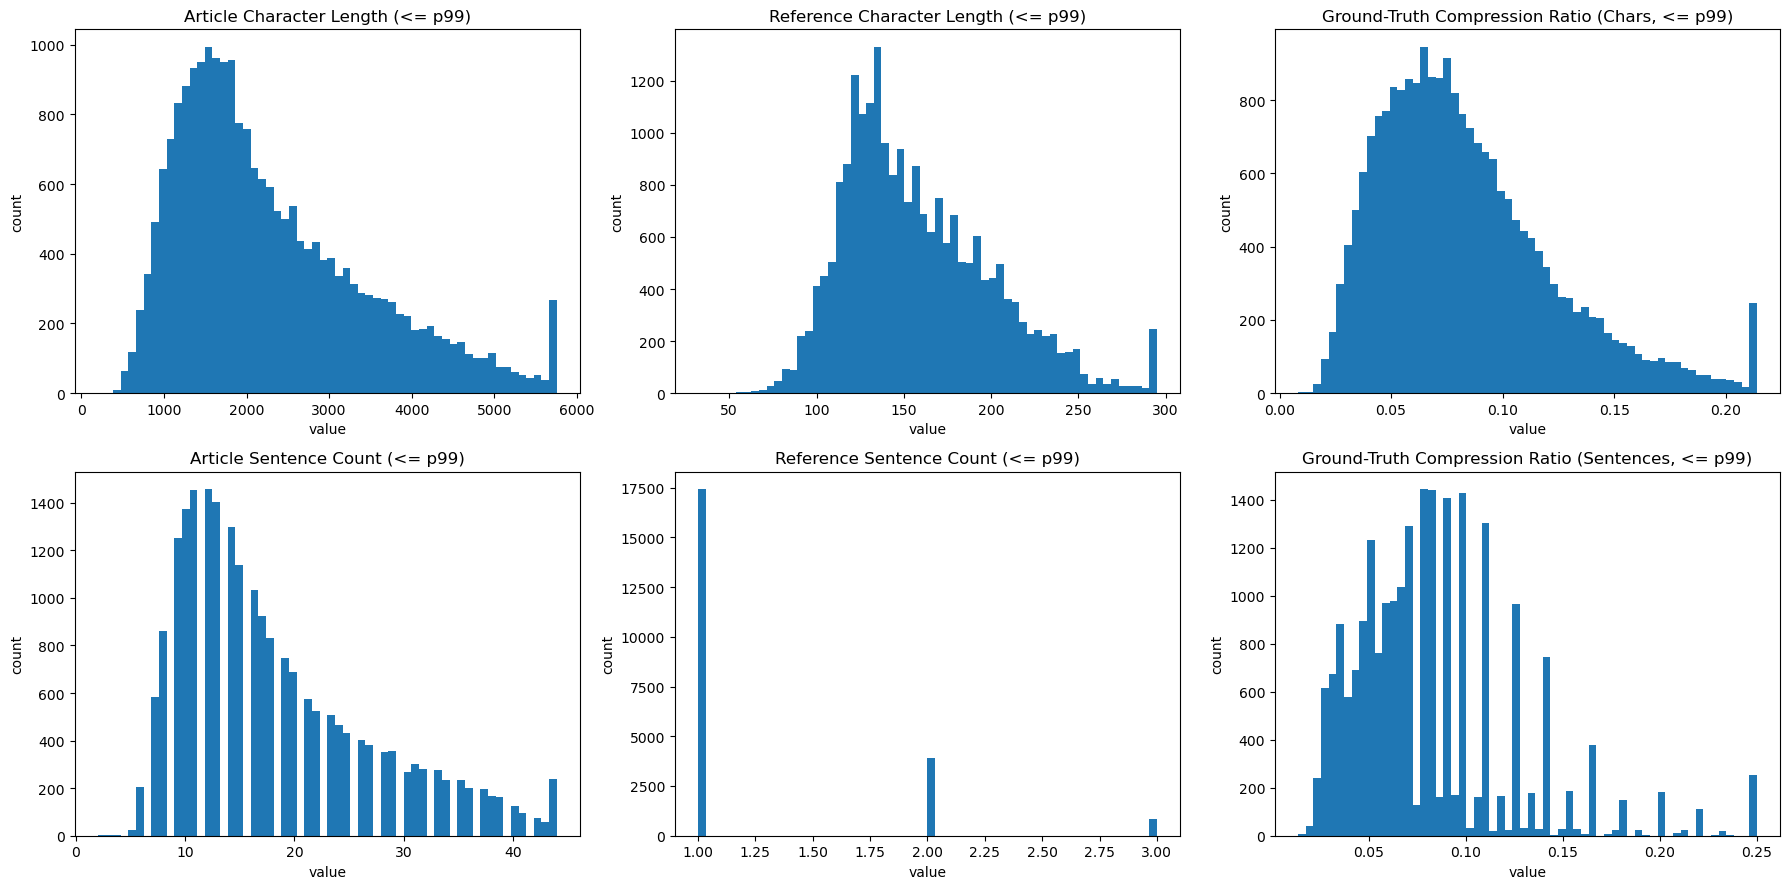

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

axes[0, 0].hist(df["article_char_len"].clip(upper=df["article_char_len"].quantile(0.99)), bins=60)
axes[0, 0].set_title("Article Character Length (<= p99)")

axes[0, 1].hist(df["reference_char_len"].clip(upper=df["reference_char_len"].quantile(0.99)), bins=60)
axes[0, 1].set_title("Reference Character Length (<= p99)")

axes[0, 2].hist(df["compression_ratio_chars"].clip(upper=df["compression_ratio_chars"].quantile(0.99)), bins=60)
axes[0, 2].set_title("Ground-Truth Compression Ratio (Chars, <= p99)")

axes[1, 0].hist(df["article_sentence_count"].clip(upper=df["article_sentence_count"].quantile(0.99)), bins=60)
axes[1, 0].set_title("Article Sentence Count (<= p99)")

axes[1, 1].hist(df["reference_sentence_count"].clip(upper=df["reference_sentence_count"].quantile(0.99)), bins=60)
axes[1, 1].set_title("Reference Sentence Count (<= p99)")

axes[1, 2].hist(df["compression_ratio_sentences"].clip(upper=df["compression_ratio_sentences"].quantile(0.99)), bins=60)
axes[1, 2].set_title("Ground-Truth Compression Ratio (Sentences, <= p99)")

for ax in axes.flat:
    ax.set_xlabel("value")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()


## 9. Curated Sample Inspection

This section is optional for reporting, but useful for manual sanity checking before the benchmark phase.

In [84]:
sample_df = df.sample(n=min(SAMPLE_N, len(df)), random_state=SEED).copy()
display_cols = [
    "guid",
    "title",
    "article_char_len",
    "article_sentence_count",
    "reference_char_len",
    "reference_sentence_count",
    "compression_ratio_chars",
    "compression_ratio_sentences",
]
sample_df[display_cols].sort_values("article_char_len", ascending=False)


,guid,title,article_char_len,article_sentence_count,reference_char_len,reference_sentence_count,compression_ratio_chars,compression_ratio_sentences
13160,13322,Tập_đoàn Novaland nhận chuyển_nhượng phần vốn góp gần 1.939 tỷ đồng,1839,10,195,1,0.106036,0.100000
16430,16688,Phạt tiền phụ_huynh xông vào trường tát cô_giáo,1622,13,197,2,0.121455,0.153846
563,564,Tá_hoả phát_hiện người đàn_ông tử_vong bên quốc_lộ,1281,14,153,1,0.119438,0.071429
2404,2418,"Sà_lan chở gạch lật trong đêm , 3 mẹ con chết thảm",1198,9,129,1,0.107679,0.111111
1383,1385,Ca_sĩ Phạm_Phương_Thảo ra_mắt album ' Tri_ân ',677,6,165,1,0.243722,0.166667


In [85]:
for i, (_, row) in enumerate(sample_df.head(2).iterrows(), start=1):
    print("=" * 120)
    print(f"Sample #{i} | guid={row['guid']}")
    print("Title:", str(row["title"]))
    print("-" * 120)
    print("Article preview:")
    print(str(row["article"])[:1200], "...")
    print("-" * 120)
    print("Ground-truth reference summary:")
    print(str(row["reference_summary"]))
    print("-" * 120)
    print(
        f"article_char_len={row['article_char_len']}, article_sentence_count={row['article_sentence_count']}, "
        f"reference_char_len={row['reference_char_len']}, reference_sentence_count={row['reference_sentence_count']}, "
        f"compression_ratio_chars={row['compression_ratio_chars']:.4f}, "
        f"compression_ratio_sentences={row['compression_ratio_sentences']:.4f}"
    )


Sample #1 | guid=564
Title: Tá_hoả phát_hiện người đàn_ông tử_vong bên quốc_lộ
------------------------------------------------------------------------------------------------------------------------
Article preview:
Ngày 1/9 , Công_an huyện Quỳ_Hợp đang phối_hợp với Công_an tỉnh Nghệ_An khám_nghiệm tử_thi , điều_tra nguyên_nhân một người đàn_ông tử_vong tại quốc_lộ 48D ( đoạn qua thị_trấn Quỳ_Hợp , huyện Quỳ_Hợp ) . Trước đó , vào_khoảng 14h ngày 31/8 , người_dân thị_trấn Quỳ_Hợp , huyện Quỳ_Hợp phát_hiện thi_thể một người đàn_ông nằm bên bụi tre thuộc khối 13 , cách Quốc_lộ 48D khoảng 10m . Qua nhận_dạng , nạn_nhân trên 50 tuổi , cao khoảng 1,6 m , mặc áo_mưa , quần lửng màu đen . Thời_điểm phát_hiện , thi_thể có dấu_hiệu trương phình , đang trong quá_trình phân_huỷ . Cách vị_trí phát_hiện thi_thể khoảng 10m , có 1 chiếc xe_máy Dream , không mang BKS . Nhận được tin báo , Công_an huyện Quỳ_Hợp phối_hợp với Công_an tỉnh Nghệ_An đến khám_nghiệm tử_thi , phát thông_tin tìm danh_tính nạn

## 10. Final Conclusions

In [86]:
distribution_summary = {
    "article_char_len_p50": float(df["article_char_len"].quantile(0.50)),
    "article_char_len_p90": float(df["article_char_len"].quantile(0.90)),
    "reference_char_len_p50": float(df["reference_char_len"].quantile(0.50)),
    "reference_char_len_p90": float(df["reference_char_len"].quantile(0.90)),
    "compression_ratio_chars_mean": float(df["compression_ratio_chars"].mean()),
    "compression_ratio_chars_p90": float(df["compression_ratio_chars"].quantile(0.90)),
}

conclusion = {
    "data_health": {
        "required_columns_present": len(missing_cols) == 0,
        "meta_key_coverage_is_100_percent": meta_keys_full,
        "article_empty_ratio": article_empty_ratio,
        "reference_summary_empty_ratio": reference_empty_ratio,
        "pass_conditions": pass_conditions,
    },
    "protocol_consistency": {
        "preprocess_check": preprocess_check,
        "interpretation": preprocess_interpretation,
    },
    "distribution_summary": distribution_summary,
}
conclusion


{'data_health': {'required_columns_present': True,
  'meta_key_coverage_is_100_percent': True,
  'article_empty_ratio': 0.0,
  'reference_summary_empty_ratio': 0.0,
  'pass_conditions': {'required_columns_present': True,
   'meta_key_coverage_is_100_percent': True,
   'article_empty_ratio_near_zero': True,
   'reference_summary_empty_ratio_near_zero': True}},
 'protocol_consistency': {'preprocess_check': {'sample_size': 500,
   'manifest_protocol_version': 'phase0_v2',
   'article_char_mismatch': 0,
   'reference_char_mismatch': 0,
   'article_sentence_mismatch': 213,
   'reference_sentence_mismatch': 61,
   'protocol_version_mismatch': 0},
  'interpretation': {'preprocessing_consistent_strict': False,
   'acceptable_for_benchmark': False,
   'sentence_mismatch_rate': 0.274,
   'possible_cause_if_nonzero': 'Sentence-count mismatches typically indicate sentence-splitting drift or tokenization differences between the stored metadata and the current preprocessing helper.',
   'impact_asse

## 11. Save Official JSON Artifact

The exported artifact is intended to be referenced directly in the thesis experiment appendix and data QA section.

In [87]:
official_export_gate = all(pass_conditions.values()) and preprocess_interpretation["acceptable_for_benchmark"]
if not official_export_gate:
    raise RuntimeError(
        "Official data QA export is blocked because one or more QA conditions failed. "
        "Review pass_conditions and preprocess_interpretation before exporting an official artifact."
    )

report_dir = PROJECT_ROOT / "notebooks" / "results" / "official" / "validation"
report_dir.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = report_dir / f"vietnews_data_check_summary_{TARGET_SPLIT}_{ts}.json"

summary_payload = {
    "report_schema_version": NOTEBOOK_SCHEMA_VERSION,
    "notebook": "01_vietnews_data_check.ipynb",
    "run_purpose": "official_thesis_data_qa",
    "target_split": TARGET_SPLIT,
    "rows": int(len(df)),
    "timestamp": ts,
    "protocol_version": protocol_version,
    "manifest_path": str(MANIFEST_PATH),
    "manifest_global_stats": manifest.get("global_stats", {}),
    "manifest_split_stats": (manifest.get("splits") or {}).get(TARGET_SPLIT, {}),
    "environment": environment_snapshot,
    "config_snapshot": config_snapshot,
    "schema": schema_df.to_dict(orient="records"),
    "meta_schema": meta_schema_df.to_dict(orient="records"),
    "pass_conditions": pass_conditions,
    "official_export_gate": official_export_gate,
    "length_stats": length_stats.to_dict(orient="records"),
    "sentence_stats": sentence_stats.to_dict(orient="records"),
    "compression_stats": compression_stats.to_dict(orient="records"),
    "preprocess_check": preprocess_check,
    "preprocess_interpretation": preprocess_interpretation,
    "conclusion": conclusion,
}

with out_path.open("w", encoding="utf-8") as f:
    json.dump(summary_payload, f, ensure_ascii=False, indent=2)

print("Saved official data QA summary:", out_path)
summary_payload


RuntimeError: Official data QA export is blocked because one or more QA conditions failed. Review pass_conditions and preprocess_interpretation before exporting an official artifact.